# K-Means 实战：啤酒数据集聚类分析

> **配套教程**：本文档是 [02_Kmeans聚类算法.md](02_Kmeans聚类算法.md) 的配套实战代码。

本 Notebook 演示如何使用 K-Means 算法对啤酒数据集进行聚类分析。我们将经历数据预处理、K 值选择、模型训练及结果可视化的完整流程。

## 1. 导入必要的库

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 数据加载与探索
加载 `beer.csv` 数据集，并查看数据的基本信息。

In [12]:
# 读取数据集
beer = pd.read_csv('beer.csv')

# 查看前 5 行
beer.head()

,Number,Name,Calories,Sodium,Alcohol,Cost
0,0,Budweiser,144,15,4.7,0.43
1,1,Schlitz,151,19,4.9,0.43
2,2,Lowenbrau,157,15,0.9,0.48
3,3,Kronenbourg,170,7,5.2,0.73
4,4,Heineken,152,11,5.0,0.77


In [13]:
# 选择用于聚类的特征
features = ['Calories', 'Sodium', 'Alcohol', 'Cost']
X = beer[features]

# 查看数据描述统计
X.describe()

,Calories,Sodium,Alcohol,Cost
count,20.000000,20.000000,20.000000,20.000000
mean,132.550000,14.950000,4.240000,0.494500
std,30.283702,6.581273,1.087924,0.144858
min,68.000000,6.000000,0.900000,0.280000
25%,110.250000,9.500000,4.175000,0.427500
50%,144.000000,15.000000,4.600000,0.435000
75%,150.250000,19.000000,4.900000,0.485000
max,175.000000,27.000000,5.500000,0.790000


### 数据相关性可视化
使用散点图矩阵查看各特征之间的关系。

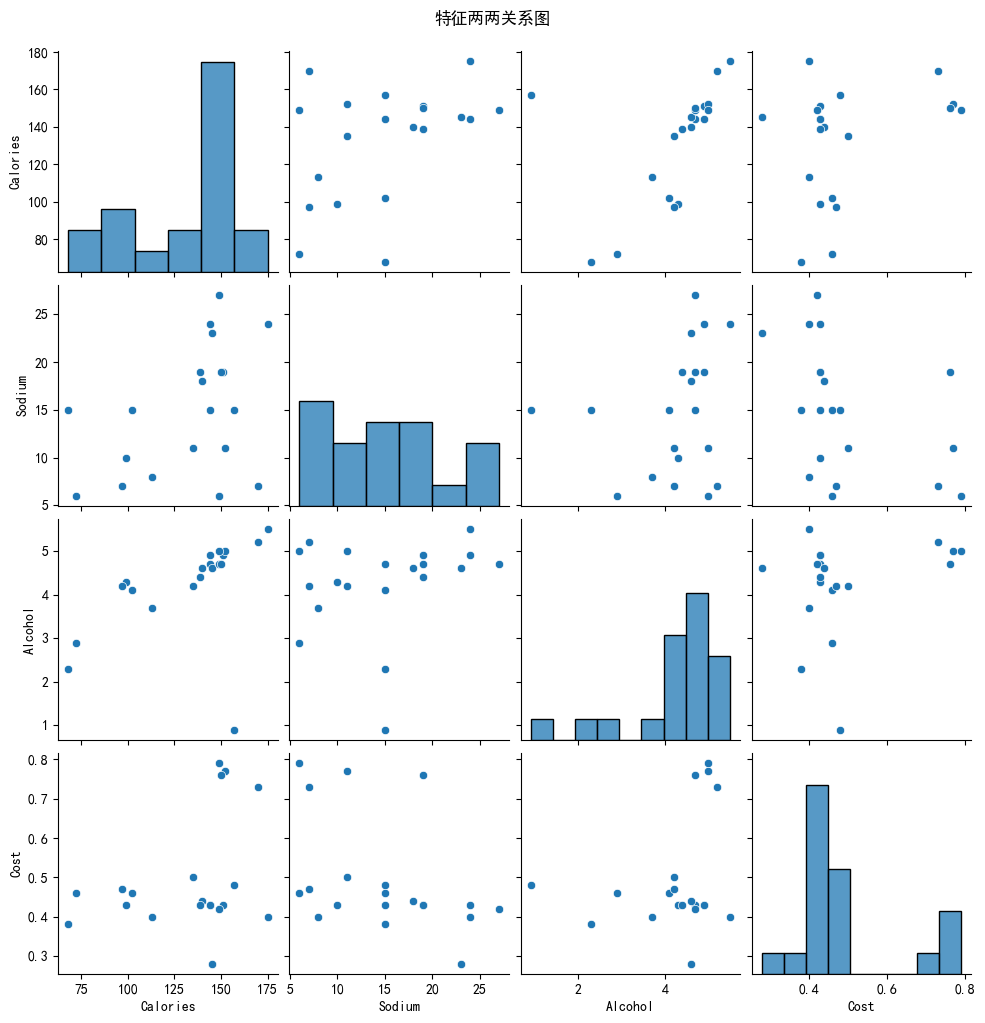

In [14]:
sns.pairplot(X)
plt.suptitle('特征两两关系图', y=1.02)
plt.show()

## 3. 数据预处理
K-Means 算法基于距离计算，因此特征的尺度差异会严重影响聚类结果。我们需要对数据进行标准化处理（Z-Score Normalization）。

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 转换为 DataFrame 方便查看（可选）
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,Calories,Sodium,Alcohol,Cost
0,0.387913,0.007795,0.433808,-0.456830
1,0.625066,0.631369,0.622420,-0.456830
2,0.828339,0.007795,-3.149822,-0.102698
3,1.268765,-1.239354,0.905338,1.667960
4,0.658944,-0.615780,0.716726,1.951265


## 4. 确定最优 K 值
使用**轮廓系数（Silhouette Score）**法来评估不同 K 值的聚类效果。轮廓系数越接近 1，表示聚类效果越好。

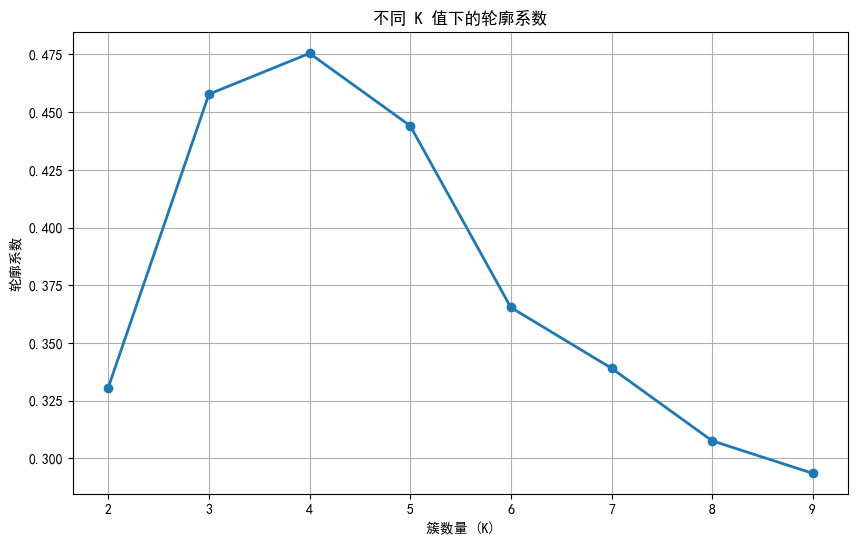

In [16]:
scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    scores.append(score)

# 绘制轮廓系数曲线
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o', linestyle='-', linewidth=2)
plt.xlabel('簇数量 (K)')
plt.ylabel('轮廓系数')
plt.title('不同 K 值下的轮廓系数')
plt.grid(True)
plt.show()

根据上图，选择轮廓系数较高的 K 值。通常 K=3 是一个不错的选择。

## 5. 模型训练与结果分析
设定 K=3，训练最终的 K-Means 模型。

In [17]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# 将聚类标签添加到原始数据中
beer['cluster'] = kmeans.labels_

### 聚类结果可视化
选取两个具有代表性的特征（例如热量和酒精含量）来展示聚类结果。

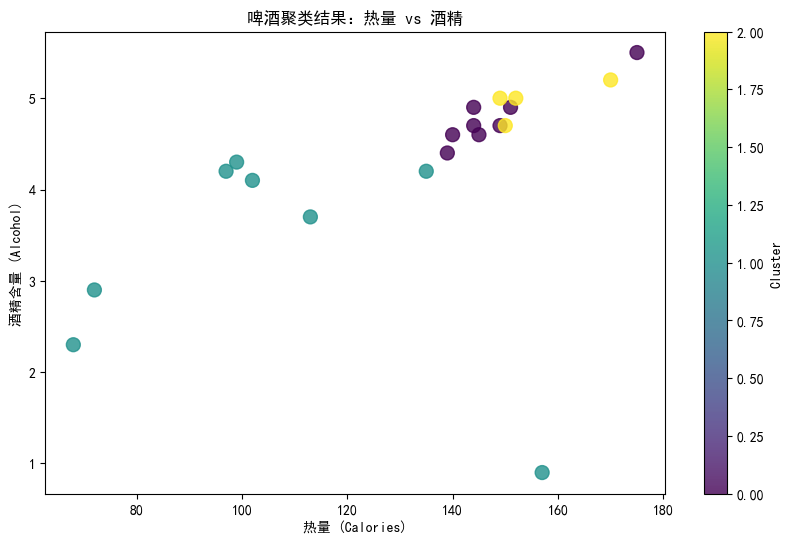

In [18]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(beer['Calories'], beer['Alcohol'], c=beer['cluster'], cmap='viridis', s=100, alpha=0.8)
plt.xlabel('热量 (Calories)')
plt.ylabel('酒精含量 (Alcohol)')
plt.title('啤酒聚类结果：热量 vs 酒精')
plt.colorbar(scatter, label='Cluster')
plt.show()

### 簇特征分析
计算每个簇的质心（均值），以理解每个簇的业务含义。

In [19]:
# 计算各簇的均值
cluster_means = beer.groupby('cluster')[features].mean()
print("各簇均值中心：")
display(cluster_means)

各簇均值中心：


,Calories,Sodium,Alcohol,Cost
cluster,,,,
0,148.375,21.125,4.7875,0.4075
1,105.375,10.875,3.3250,0.4475
2,155.250,10.750,4.9750,0.7625


### 查看各簇包含的具体品牌

In [20]:
for i in range(k):
    print(f"\n簇 {i} 包含的品牌:")
    print(beer[beer['cluster'] == i]['Name'].values)


簇 0 包含的品牌:
['Budweiser' 'Schlitz' 'Old_Milwaukee' 'Augsberger' 'Srohs_Bohemian_Style'
 'Coors' 'Hamms' 'Heilemans_Old_Style']

簇 1 包含的品牌:
['Lowenbrau' 'Miller_Lite' 'Budweiser_Light' 'Coors_Light'
 'Michelob_Light' 'Pabst_Extra_Light' 'Olympia_Goled_Light'
 'Schlitz_Light']

簇 2 包含的品牌:
['Kronenbourg' 'Heineken' 'Becks' 'Kirin']
